In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTANT NOTICE

Originally I wrote this notebook and final report on a machine with differnt versions of the libraries, and when I was transfering everying into the repo I realized that the versions used were not running. After some minor debugging I got this notebook to run just fine, however, some of the outputs in here will look slightly differnt then the figures in the report and it was too late to rewrite everything. Reguardelss, all of the analysis there should still stand. Thanks for reading this.

# Loading the Data

In [7]:
# Assembling Datasets
pokemon_df = pd.read_csv('!!!Local path to poke_ds.csv!!!')
pokemon_df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


In [8]:
print(pokemon_df.columns.tolist())

['abilities', 'against_bug', 'against_dark', 'against_dragon', 'against_electric', 'against_fairy', 'against_fight', 'against_fire', 'against_flying', 'against_ghost', 'against_grass', 'against_ground', 'against_ice', 'against_normal', 'against_poison', 'against_psychic', 'against_rock', 'against_steel', 'against_water', 'attack', 'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate', 'classfication', 'defense', 'experience_growth', 'height_m', 'hp', 'japanese_name', 'name', 'percentage_male', 'pokedex_number', 'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg', 'generation', 'is_legendary']


In [9]:
drop_columns = ['name', 'japanese_name', 'pokedex_number', 'classfication', 'abilities', 'experience_growth', 'base_happiness', 'capture_rate', 'base_egg_steps', 'generation']
df = pokemon_df.drop(columns=drop_columns)
print(df.columns.tolist())

['against_bug', 'against_dark', 'against_dragon', 'against_electric', 'against_fairy', 'against_fight', 'against_fire', 'against_flying', 'against_ghost', 'against_grass', 'against_ground', 'against_ice', 'against_normal', 'against_poison', 'against_psychic', 'against_rock', 'against_steel', 'against_water', 'attack', 'base_total', 'defense', 'height_m', 'hp', 'percentage_male', 'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg', 'is_legendary']


In [ ]:
# Accessing row data based on specific filter:

# By name:
#pokemon_df[pokemon_df['name']=='Bulbasaur']

# By type:
#pokemon_df[pokemon_df['type1']=='grass']

# By Boolean Conditions:
#pokemon_df[(pokemon_df['sp_attack']>200) & (pokemon_df['sp_defense']>100)]

# Part 1: Data Exploration

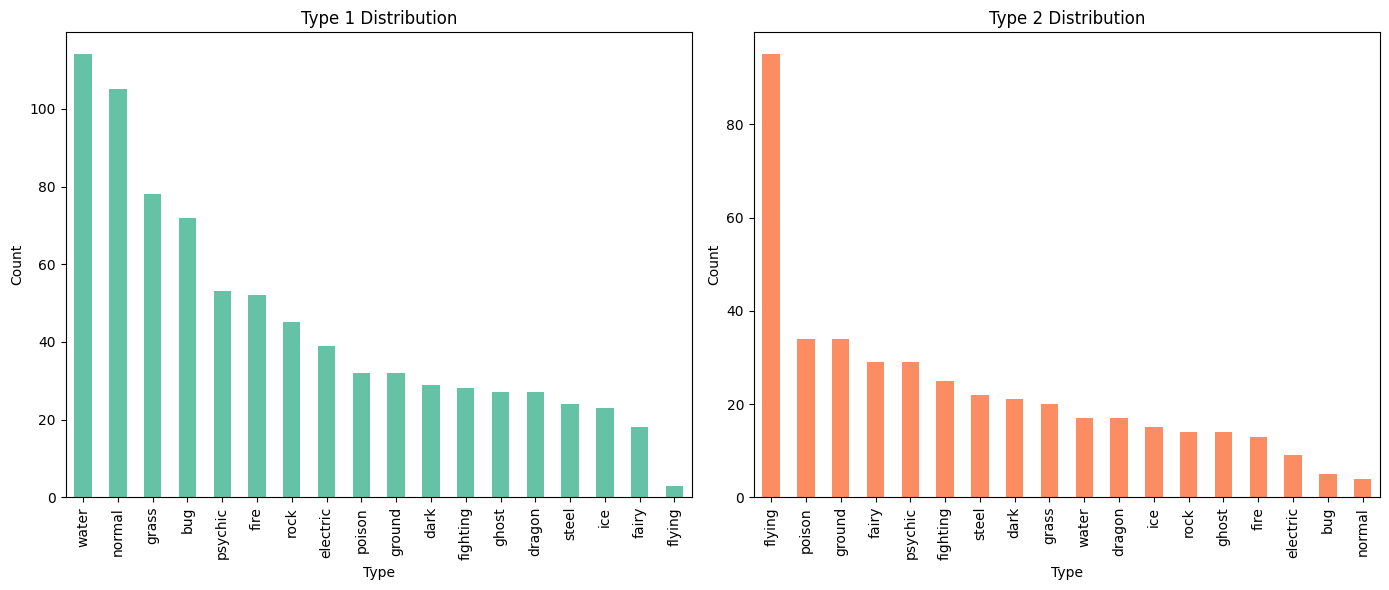

In [10]:
# Set the seaborn color palette
palette = sns.color_palette("Set2", n_colors=2)

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 'type1' value counts
pokemon_df['type1'].value_counts().plot(kind="bar", ax=axes[0], color=palette[0])
axes[0].set_title("Type 1 Distribution")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Count")

# Plot 'type2' value counts
pokemon_df['type2'].value_counts().plot(kind="bar", ax=axes[1], color=palette[1])
axes[1].set_title("Type 2 Distribution")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Count")

# Display the plots
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Count')

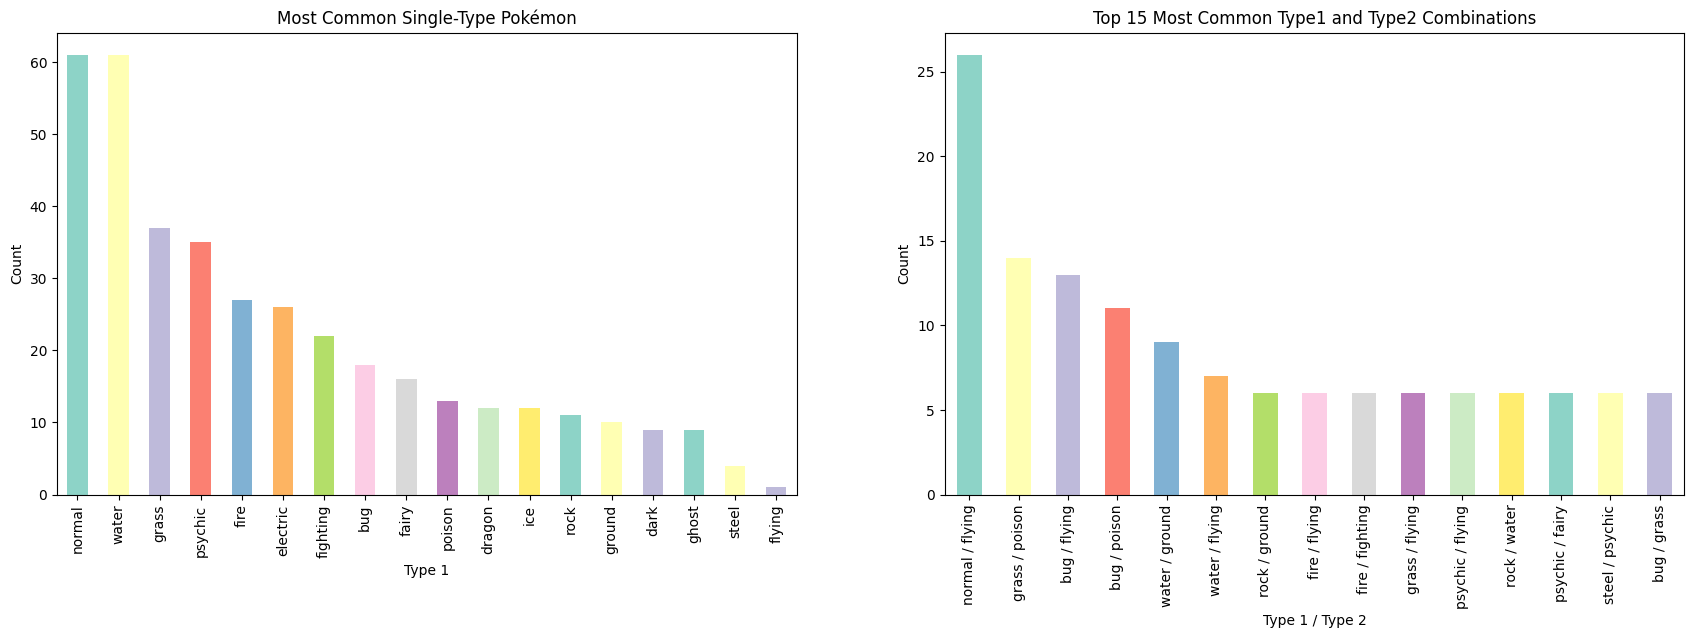

In [11]:

# Set the seaborn color palette for the bars (Top 15 and Least 15)
palette = sns.color_palette("Set3", n_colors=15)  # Using a palette with 15 distinct colors

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 2, figsize=(21, 6))  # Increased figure width for three plots

# First Graph: Most common single-type Pokémon (type2 is null)
single_type_pokemon = pokemon_df[pokemon_df['type2'].isnull()]['type1'].value_counts()
single_type_pokemon.plot(kind="bar", ax=axes[0], color=palette[:len(single_type_pokemon)])  # Unique colors for bars
axes[0].set_title("Most Common Single-Type Pokémon")
axes[0].set_xlabel("Type 1")
axes[0].set_ylabel("Count")

# Second Graph: Top 15 most common type1 and type2 combinations
# Combine type1 and type2 to create a new column for the combination
pokemon_df['type_combo'] = pokemon_df['type1'] + " / " + pokemon_df['type2'].fillna('')
# Remove Pokémon with no type2 (type2 == null)
type_combo_counts = pokemon_df[pokemon_df['type2'].notnull()]['type_combo'].value_counts()

# Select the top 15 type1/type2 combinations
top_15_type_combos = type_combo_counts.head(15)

# Plot the top 15 type1/type2 combinations with unique colors
top_15_type_combos.plot(kind="bar", ax=axes[1], color=palette[:len(top_15_type_combos)])
axes[1].set_title("Top 15 Most Common Type1 and Type2 Combinations")
axes[1].set_xlabel("Type 1 / Type 2")
axes[1].set_ylabel("Count")



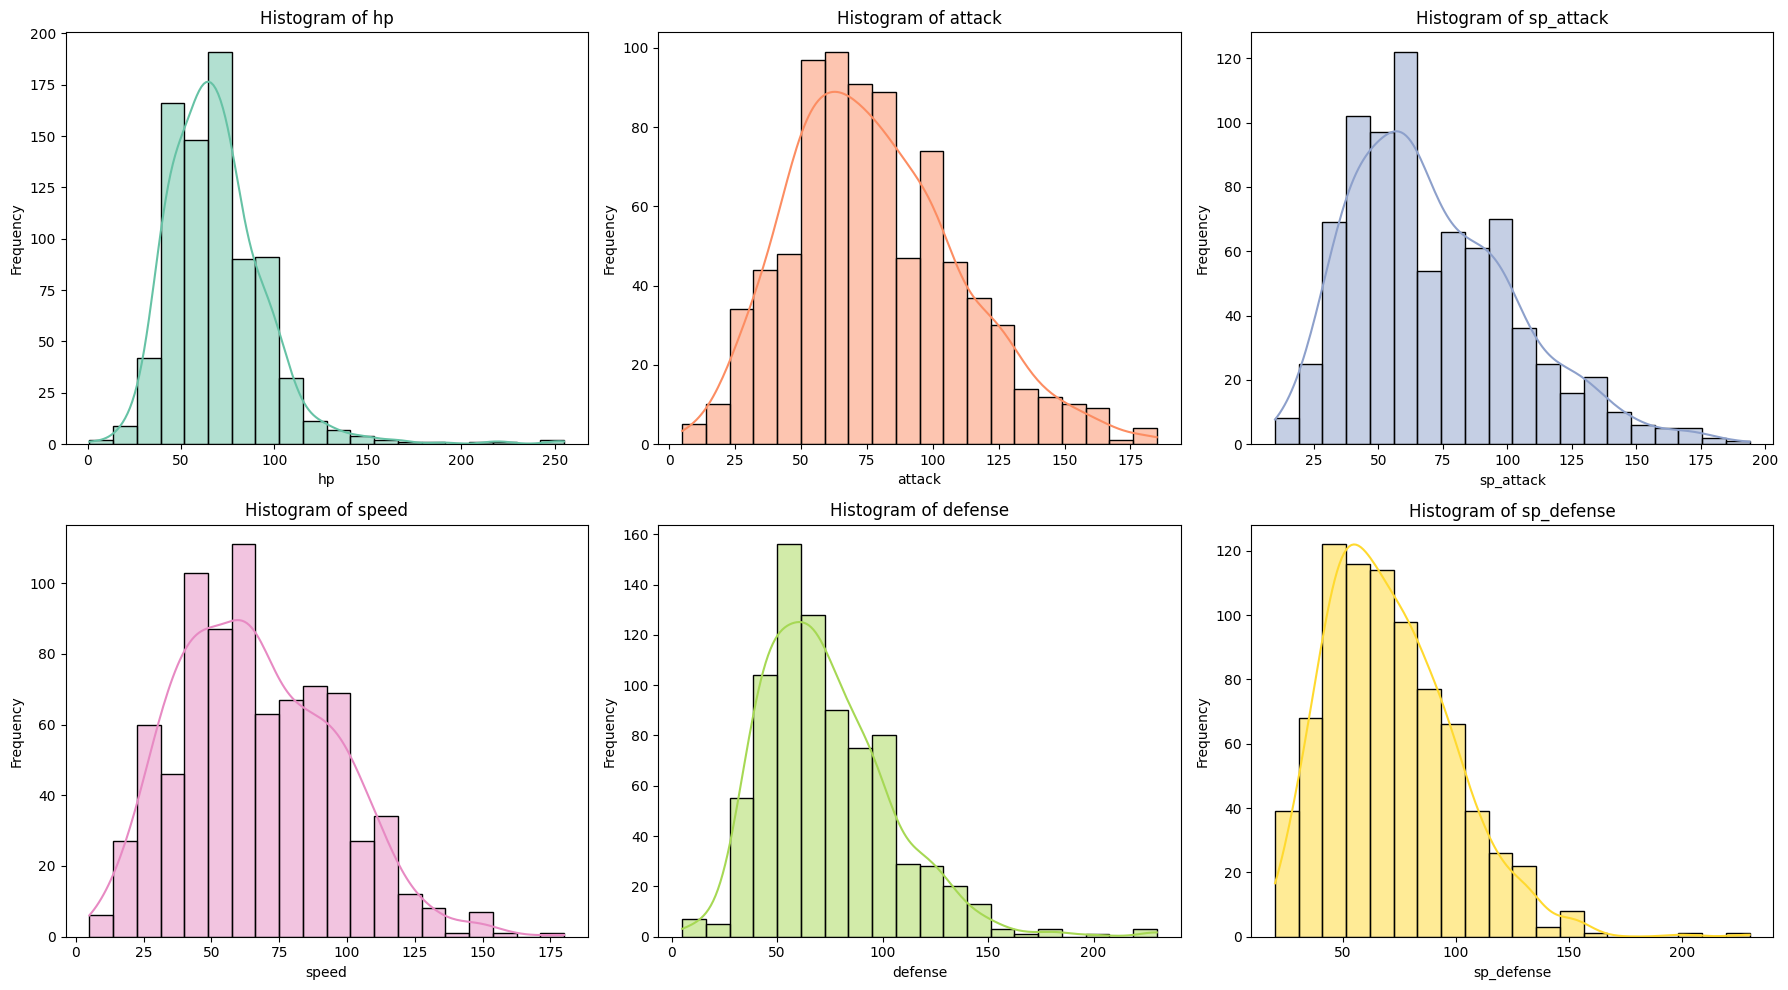

In [12]:

# List of columns to plot
columns = ['hp', 'attack', 'sp_attack', 'speed','defense', 'sp_defense']

# Define a list of colors for each plot
colors = sns.color_palette("Set2", n_colors=len(columns))  # Using seaborn color palette

# Handle potential inf values by replacing them with NaN
pokemon_df[columns] = pokemon_df[columns].replace([np.inf, -np.inf], np.nan)

# Create a 2x3 grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes array to make indexing easier
axes = axes.flatten()

# Loop through each column and plot the histogram with different colors
for i, col in enumerate(columns):
    sns.histplot(pokemon_df[col], kde=True, ax=axes[i], color=colors[i], bins=20)
    axes[i].set_title(f"Histogram of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Adjust layout to avoid overlapping labels
plt.tight_layout()
plt.show()


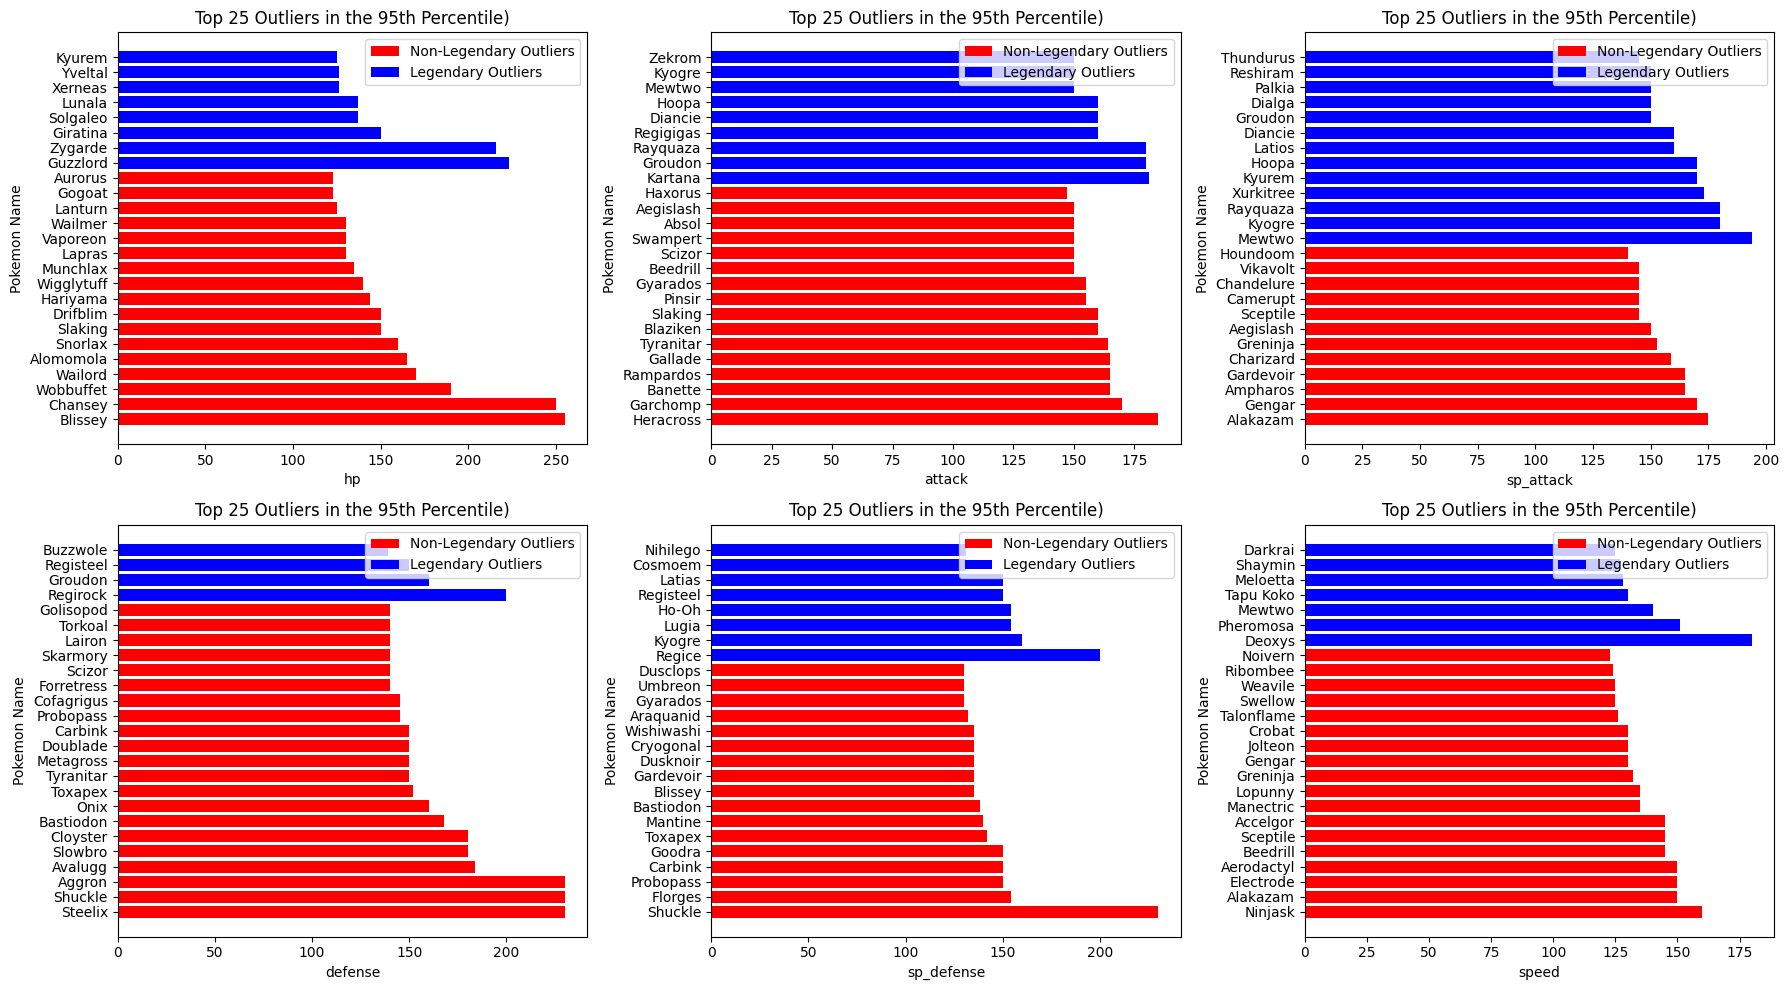

In [13]:
# List of columns to analyze
columns = ['hp', 'attack', 'sp_attack', 'defense', 'sp_defense', 'speed']

# Define a list of colors for each plot
colors = sns.color_palette("Set2", n_colors=len(columns))

# Create a 2x3 grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes array to make indexing easier
axes = axes.flatten()

# Loop through each column to plot the top 25 outliers
for i, col in enumerate(columns):
    # Calculate the 95th percentile
    percentile_95 = pokemon_df[col].quantile(0.95)

    # Identify the outliers (values greater than the 95th percentile)
    outliers = pokemon_df[pokemon_df[col] > percentile_95]

    # Sort outliers in descending order and select the top 25
    top_25_outliers = outliers.nlargest(25, col)

    # Separate legendary and non-legendary Pokémon
    legendary_outliers = top_25_outliers[top_25_outliers['is_legendary'] == 1]
    non_legendary_outliers = top_25_outliers[top_25_outliers['is_legendary'] == 0]

    # Plot non-legendary outliers (in red)
    axes[i].barh(non_legendary_outliers['name'], non_legendary_outliers[col], color='red', label='Non-Legendary Outliers')

    # Plot legendary outliers (in blue)
    axes[i].barh(legendary_outliers['name'], legendary_outliers[col], color='blue', label='Legendary Outliers')

    # Set titles and labels
    axes[i].set_title(f"Top 25 Outliers in the 95th Percentile)")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Pokemon Name")

    # Add a legend
    axes[i].legend()

# Adjust layout to avoid overlapping labels
plt.tight_layout()
plt.show()


<ipython-input-14-5279eac870c2>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=generation_counts.index, y=generation_counts.values, palette='Set2')


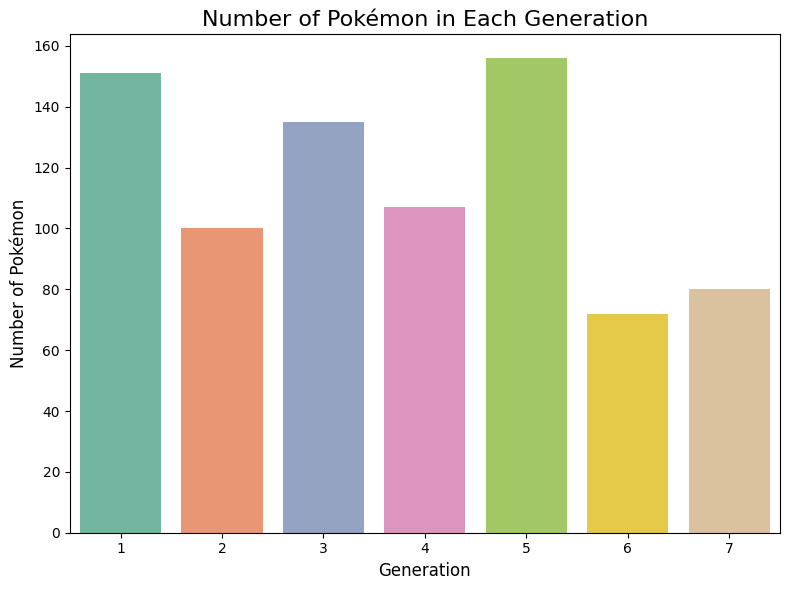

In [14]:
# Count the number of Pokémon in each generation
generation_counts = pokemon_df['generation'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=generation_counts.index, y=generation_counts.values, palette='Set2')

# Add titles and labels
plt.title("Number of Pokémon in Each Generation", fontsize=16)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Number of Pokémon", fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()


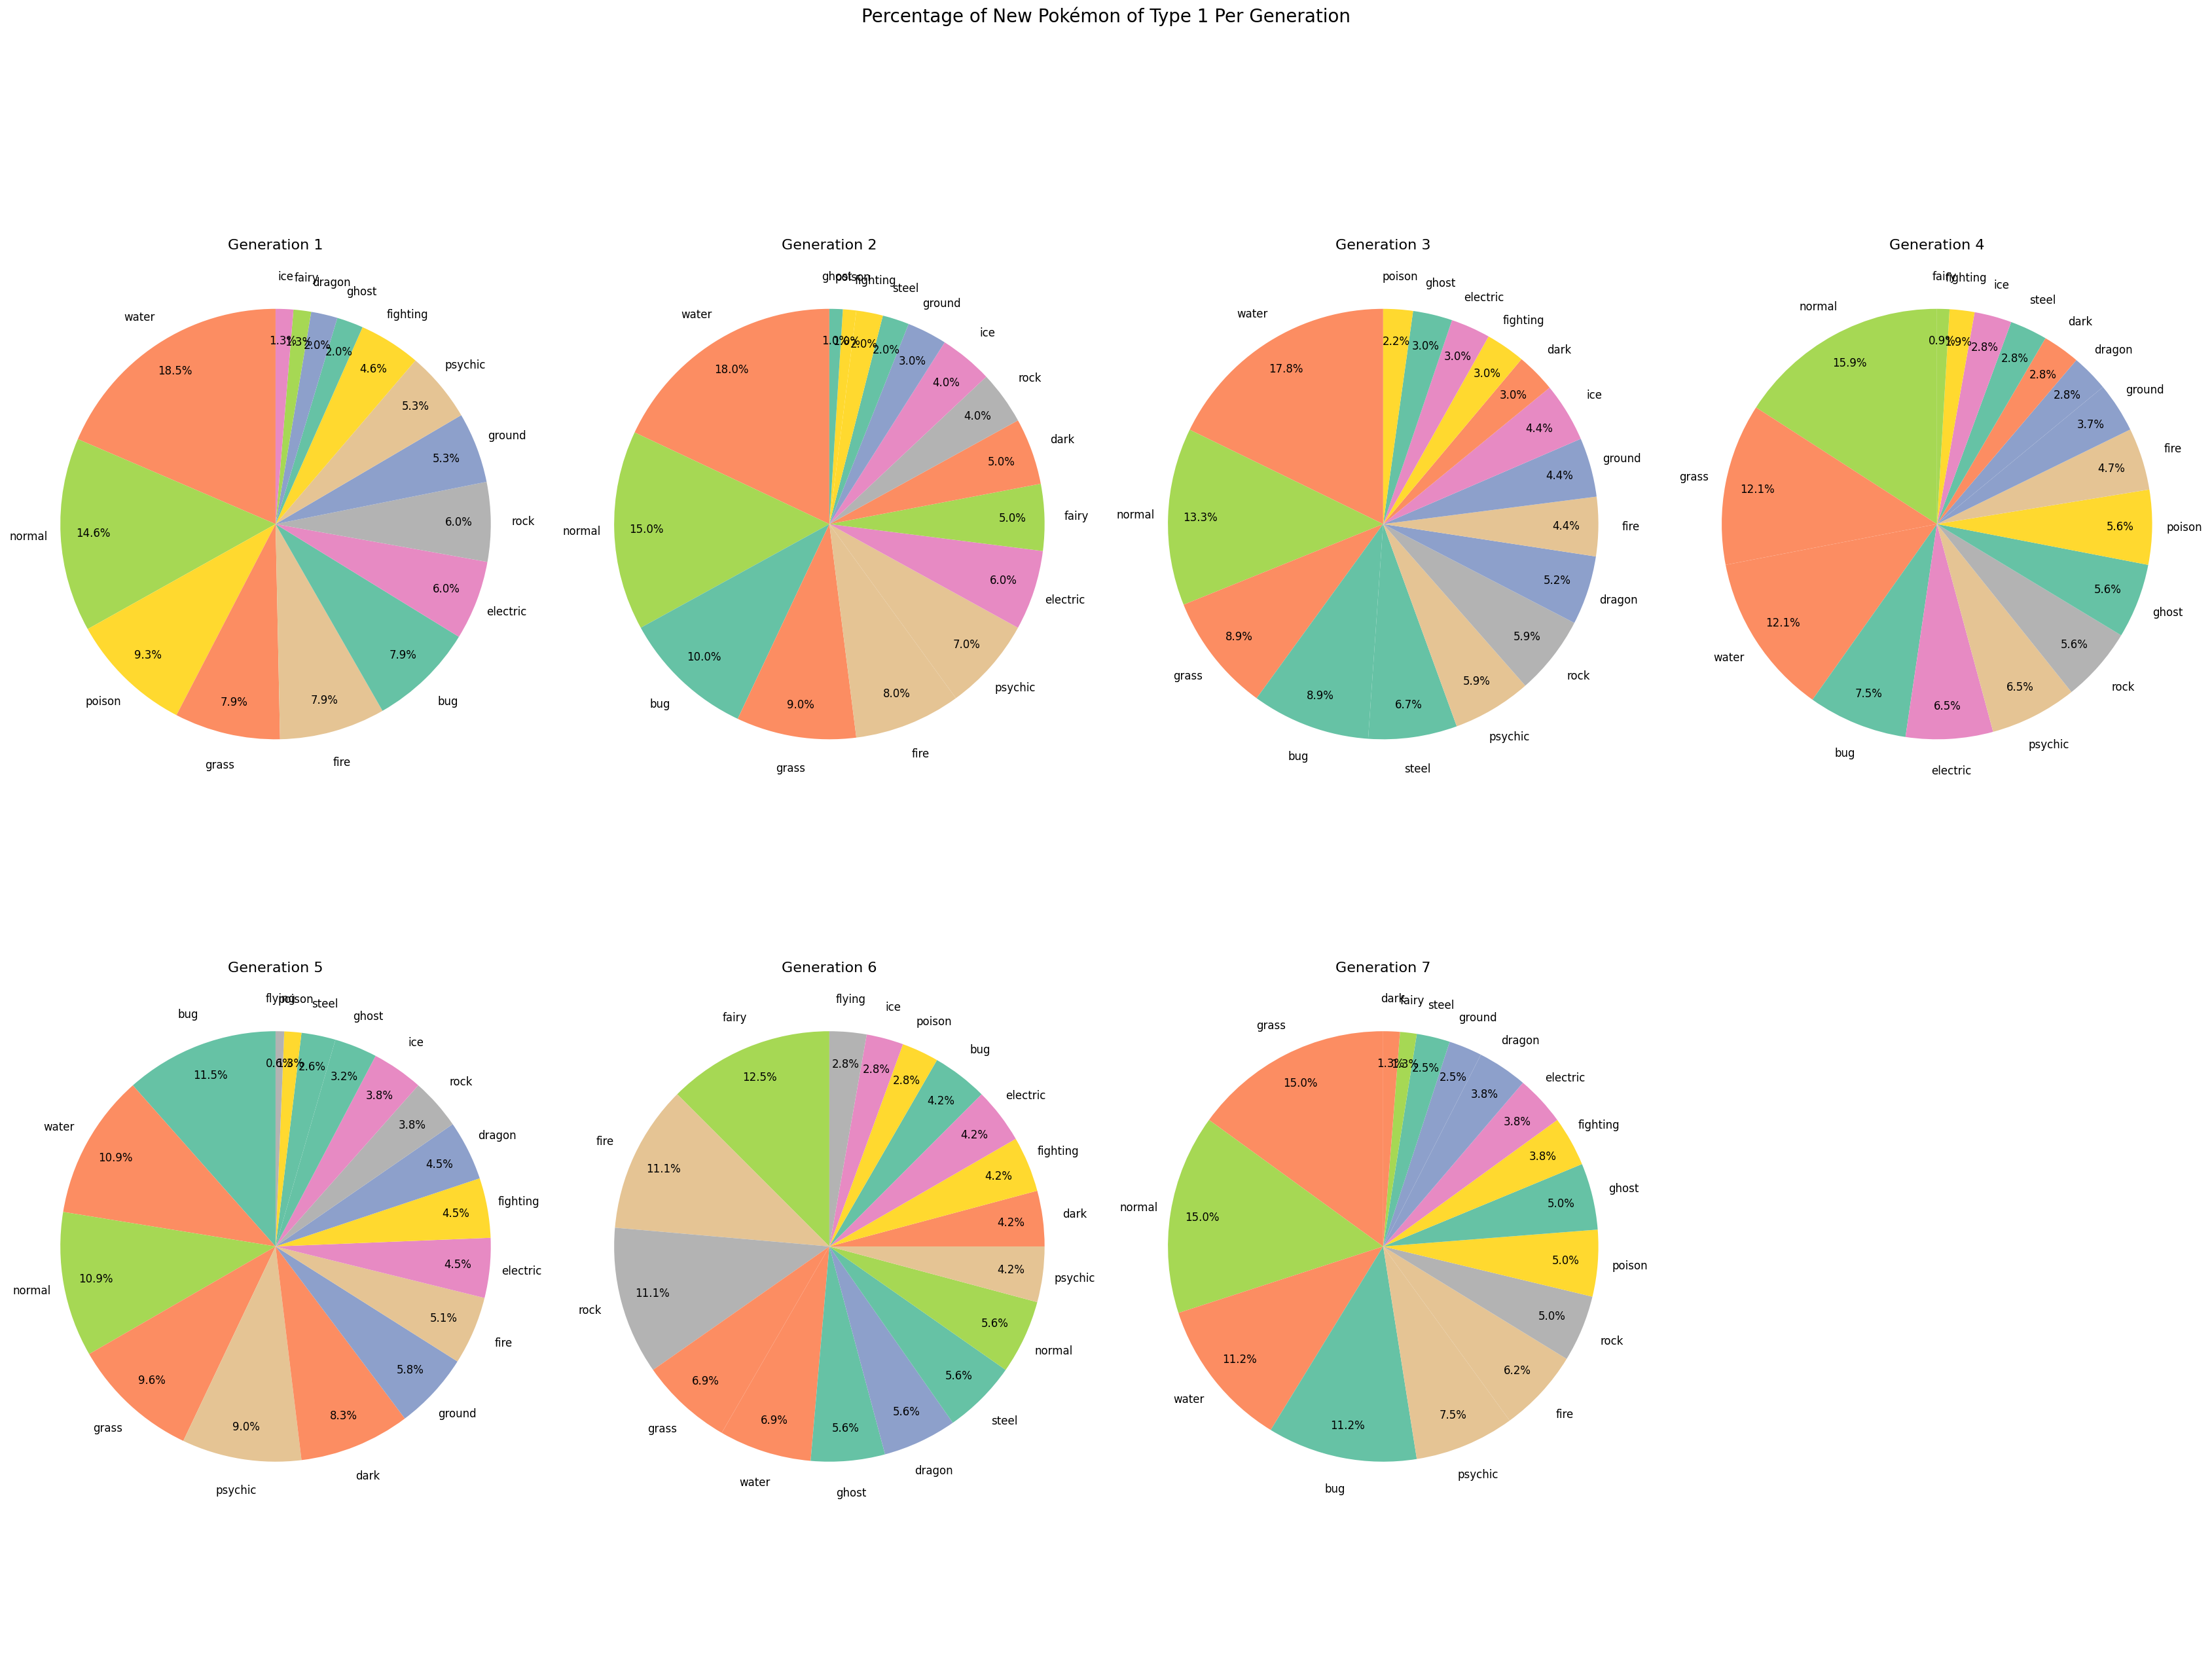

In [15]:
# List of unique Pokémon types (type1) sorted for consistency
types = sorted(pokemon_df['type1'].unique())

# Define a color palette to ensure consistent colors across all generations
colors = sns.color_palette("Set2", len(types))

# Create a mapping of each type to a specific color
type_color_map = dict(zip(types, colors))

# List of unique generations (assuming 7 generations based on Pokémon data)
generations = sorted(pokemon_df['generation'].unique())

# Set up the figure with 2 rows and 4 columns (we have 7 generations, so we'll use an extra column)
fig, axes = plt.subplots(2, 4, figsize=(34, 24))  # Increased figure size to 24x14

# Flatten the axes to make indexing easier (since 2x4 grid gives us 8 axes, and we only need 7)
axes = axes.flatten()

# Loop through each generation and plot a pie chart for the distribution of type1
for i, gen in enumerate(generations):
    # Filter the data for the current generation
    gen_data = pokemon_df[pokemon_df['generation'] == gen]

    # Count the occurrences of each type1 in the current generation
    type_counts = gen_data['type1'].value_counts()

    # Set the color for each type in the current generation using the predefined color map
    pie_colors = [type_color_map[type_] for type_ in type_counts.index]

    # Plot the pie chart
    wedges, texts, autotexts = axes[i].pie(
        type_counts,
        labels=type_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=pie_colors,
        textprops={'fontsize': 12},  # Adjust text size for clarity
        labeldistance=1.15,  # Adjust label distance to prevent overlap
        pctdistance=0.85  # Adjust the percentage text distance to fit inside
    )

    # Set title for each generation's pie chart
    axes[i].set_title(f"Generation {gen}", fontsize=16)

    # Increase the distance of the labels and values from the pie chart to avoid overlap
    for text in texts + autotexts:
        text.set_horizontalalignment('center')

    # Optional: Adjust label size or placement for better readability if necessary
    for text in texts:
        text.set_fontsize(12)

# Hide the last (empty) subplot if there's only 7 generations
axes[-1].axis('off')

# Add a global title for the entire figure
fig.suptitle("Percentage of New Pokémon of Type 1 Per Generation", fontsize=20, y=1.05)

# Adjust layout to avoid overlap and add spacing
plt.tight_layout()
plt.show()


# Part 2: Data Analysis

## Clustering Pokémon Based on Their Attributes
Question: Can we group Pokémon into distinct clusters based on their attributes like stats (attack, defense, etc.), types, and generation?
This is what we will find out here!

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.spatial.distance as ssd
from scipy.spatial.distance import cdist
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

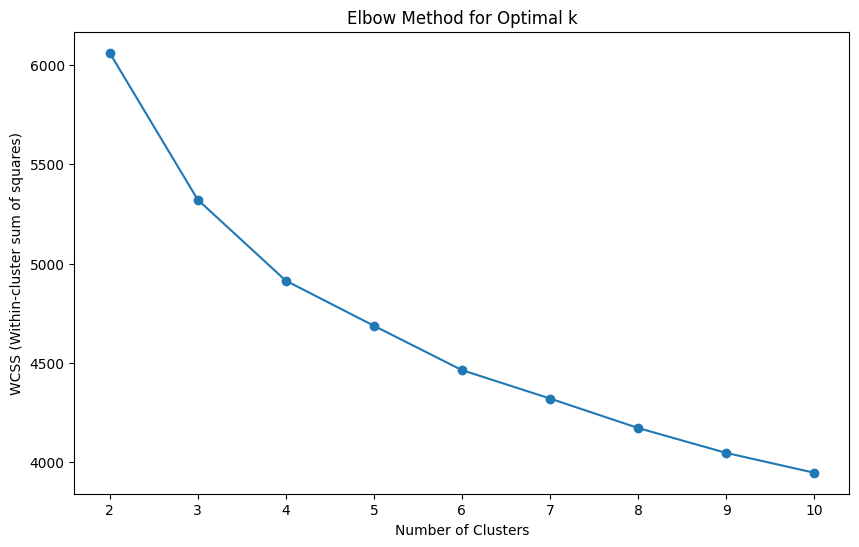

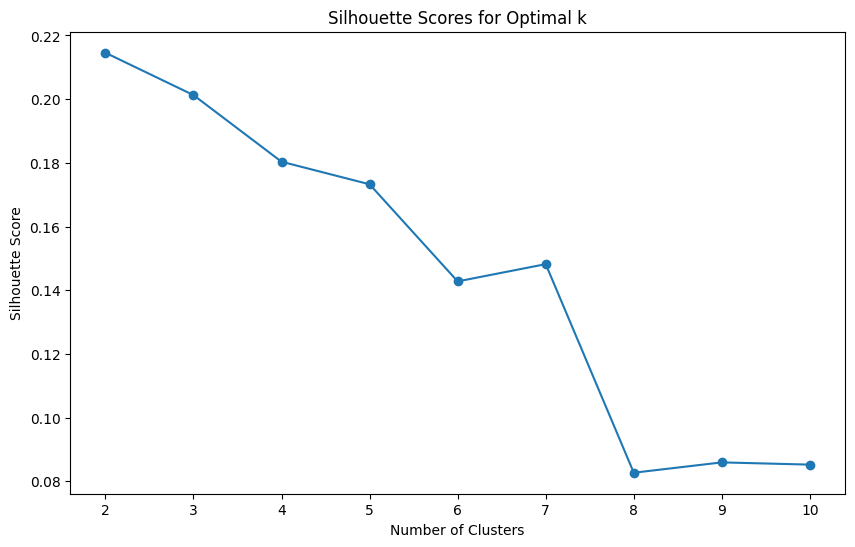

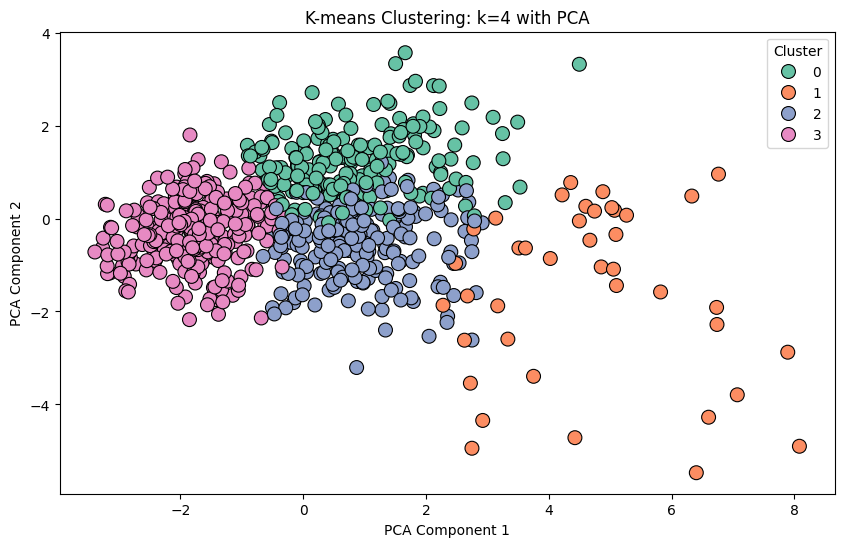

Silhouette Score for k=4: 0.1803540080850928


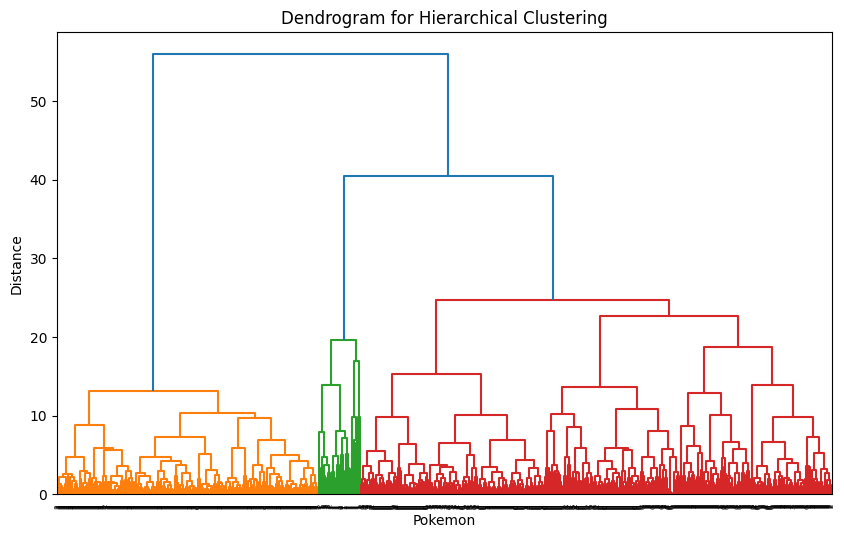

         hp    attack   defense  sp_attack  sp_defense     speed
0  0.161918  0.482823 -0.031901   0.656915    0.266113  1.172043
1  1.509491  1.334599  1.358255   0.919140    0.948562  0.379563
2  0.557582  0.310440  0.761332   0.182043    0.658787 -0.418147
3 -0.686144 -0.707826 -0.679059  -0.683603   -0.756982 -0.544171


In [29]:
# Assuming pokemon_df is your DataFrame

# Step 1: Preprocessing the Data

# Drop columns that are unlikely to be useful for clustering
drop_columns = ['japanese_name', 'pokedex_number', 'classfication', 'abilities', 'experience_growth', 'base_happiness', 'capture_rate', 'base_egg_steps']
df = pokemon_df.drop(columns=drop_columns)

# Handle missing values: We will drop rows where the 'type1' or 'type2' are missing
df = df.dropna(subset=['type1'])

# Step 2: Encode categorical columns ('type1', 'type2', 'is_legendary')
# OneHotEncode 'type1', 'type2' and 'is_legendary'
categorical_columns = ['type1', 'type2', 'is_legendary']

# List of numerical columns to scale
numerical_columns = ['height_m', 'weight_kg', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

# Define preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with mean
            ('scaler', StandardScaler())  # Scale numerical columns
        ]), numerical_columns),
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(sparse_output=False))  # Use sparse_output=False for dense matrix
        ]), categorical_columns)  # One-hot encode categorical columns
    ])

# Step 3: Fit a KMeans clustering model

# Combine everything into a pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Apply preprocessing to the data
X = pipeline.fit_transform(df)

# Step 4: K-means Clustering

# Determine the number of clusters (K) using the Elbow method and Silhouette score
wcss = []
sil_scores = []

# Try different values of k to find the optimal number of clusters
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, kmeans.labels_))

# Plot the Elbow method (WCSS)
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Within-cluster sum of squares)")
plt.show()

# Plot Silhouette scores to evaluate clustering quality
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.title("Silhouette Scores for Optimal k")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

# From the Elbow and Silhouette plot, choose the best k
best_k = 4  # going to pick 4, but this is more of an art than a science

# Fit K-means with the best k
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans.fit(X)

# Add the cluster labels back to the original dataframe
df['cluster'] = kmeans.labels_

# Step 5: Visualize clusters using PCA

# Reduce dimensions using PCA to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot the PCA results with cluster labels
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='Set2', s=100, edgecolor='black')
plt.title(f"K-means Clustering: k={best_k} with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster", loc='upper right')
plt.show()

# Step 6: Evaluate the clustering quality
sil_score = silhouette_score(X, kmeans.labels_)
print(f"Silhouette Score for k={best_k}: {sil_score}")

# Step 7: Hierarchical Clustering and Dendrogram

# X is a dense matrix because we specified sparse_output=False in OneHotEncoder
# To ensure we only pass numerical data to linkage, we'll extract only the numerical part
X_numerical = X[:, :len(numerical_columns)]  # Extract only the numerical features

# Now, we can calculate the linkage matrix using only numerical features.
Z = linkage(X_numerical, 'ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df['cluster'].values)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Pokemon")
plt.ylabel("Distance")
plt.show()

# Step 8: Interpretation of Clusters

# Cluster analysis based on stats: HP, Attack, Defense, etc.
cluster_centroids = pd.DataFrame(kmeans.cluster_centers_)
cluster_centroids.columns = numerical_columns + [f"type1_{i}" for i in range(len(df['type1'].unique()))] + [f"type2_{i}" for i in range(len(df['type2'].unique()))] + ['is_legendary_0', 'is_legendary_1']

# For example, let's see the stats for each cluster
print(cluster_centroids[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']])


In [28]:
# Add PCA components and cluster labels to the dataframe for easy access
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
df['cluster'] = kmeans.labels_

# Get the centroids of each cluster (these are already calculated by kmeans)
centroids = kmeans.cluster_centers_

# Function to calculate the distance between points and cluster centroids
def get_closest_pokemon(cluster_number):
    # Filter Pokémon by the cluster number
    cluster_data = df[df['cluster'] == cluster_number]

    # Get the centroid for the cluster (only PCA1 and PCA2 components)
    centroid = centroids[cluster_number][:2]  # Ensure we are using only the first 2 components

    # Calculate the Euclidean distance between the Pokémon and the cluster centroid
    distances = cdist(cluster_data[['PCA1', 'PCA2']], [centroid], metric='euclidean')

    # Add the distances to the DataFrame
    cluster_data['distance_to_centroid'] = distances

    # Sort by distance to centroid and get the top 5 Pokémon
    top_5_pokemon = cluster_data.nsmallest(5, 'distance_to_centroid')[['name', 'distance_to_centroid', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']]

    return top_5_pokemon

# Get the top 5 most representative Pokémon for each cluster
top_5_per_cluster = {}

for cluster_num in range(best_k):  # Use 'best_k' as the number of clusters you selected
    top_5_per_cluster[cluster_num] = get_closest_pokemon(cluster_num)

# Format the top 5 Pokémon for each cluster into a single DataFrame
formatted_results = []

for cluster_num, top_pokemon in top_5_per_cluster.items():
    # Add the cluster number to the table for identification
    top_pokemon['Cluster'] = cluster_num

    # Append to the final results list
    formatted_results.append(top_pokemon)

# Concatenate all the top Pokémon into a single DataFrame
final_df = pd.concat(formatted_results)

# Set the display order of columns (optional: for better readability)
final_df = final_df[['Cluster', 'name', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'distance_to_centroid']]

# Display the result as a well-formatted table
final_df.reset_index(drop=True, inplace=True)

# Now, simply display the DataFrame without the index column:
final_df.style.set_table_styles(
    [{'selector': 'thead th', 'props': [('background-color', '#f2f2f2'), ('text-align', 'center')]},
     {'selector': 'tbody td', 'props': [('text-align', 'center')]},
     {'selector': 'table', 'props': [('width', '100%')]},
     {'selector': 'thead', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
     {'selector': 'tbody', 'props': [('font-size', '12px')]},
     {'selector': 'table', 'props': [('border-collapse', 'collapse')]},
     {'selector': 'th', 'props': [('border', '1px solid #ccc')]},
     {'selector': 'td', 'props': [('border', '1px solid #ccc')]},
     {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f9f9f9')]}, # Zebra stripes
    ]
)  # This should not be needed anymore as we are not using the index

final_df


<ipython-input-28-89515d70bddb>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['distance_to_centroid'] = distances
<ipython-input-28-89515d70bddb>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['distance_to_centroid'] = distances
<ipython-input-28-89515d70bddb>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

,Cluster,name,hp,attack,defense,sp_attack,sp_defense,speed,distance_to_centroid
0,0,Breloom,60,130,80,60,60,70,0.270481
1,0,Gabite,68,90,65,50,55,82,0.337792
2,0,Vigoroth,80,80,80,55,55,90,0.347194
3,0,Sawk,75,125,75,30,75,85,0.356733
4,0,Furret,85,76,64,45,55,90,0.384400
5,1,Lunala,137,113,89,137,107,97,2.830446
6,1,Xerneas,126,131,95,131,98,99,2.991950
7,1,Necrozma,97,107,101,127,89,79,3.171870
8,1,Kyurem,125,120,90,170,100,95,3.294304
9,1,Cobalion,91,90,129,90,72,108,3.392976


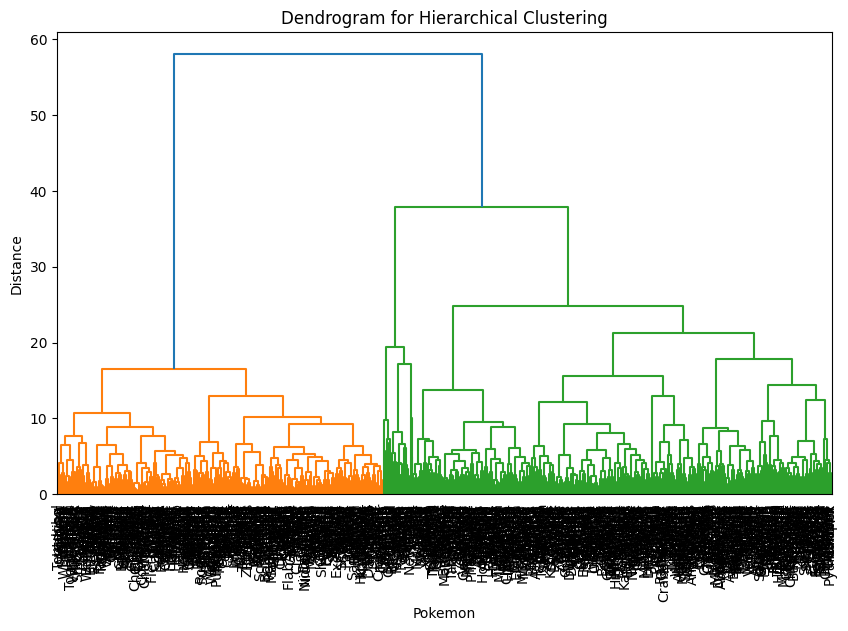

<ipython-input-30-0587d7880496>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['distance_to_centroid'] = distances
<ipython-input-30-0587d7880496>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data['distance_to_centroid'] = distances
<ipython-input-30-0587d7880496>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

,Cluster,name,hp,attack,defense,sp_attack,sp_defense,speed,distance_to_centroid
0,1,Snorunt,50,50,50,50,50,50,7.698172
1,1,Ditto,48,48,48,48,48,48,11.998336
2,1,Mareanie,50,53,62,43,52,45,13.847917
3,1,Pansage,50,53,48,53,48,64,14.035933
4,1,Pansear,50,53,48,53,48,64,14.035933
5,2,Necrozma,97,107,101,127,89,79,31.368615
6,2,Xerneas,126,131,95,131,98,99,32.689295
7,2,Yveltal,126,131,95,131,98,99,32.689295
8,2,Solgaleo,137,137,107,113,89,97,33.577622
9,2,Celesteela,97,101,103,107,101,61,35.164234


In [30]:
# Assuming 'df' contains the data and 'X' contains the PCA-transformed data
# Also assuming you've already calculated the linkage matrix (Z) for hierarchical clustering
Z = linkage(X, 'ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df['name'].values, orientation='top', leaf_font_size=10)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Pokemon")
plt.ylabel("Distance")
plt.show()

# Cut the tree for the optimal number of clusters
optimal_k = 4  # Change based on your visual analysis of the dendrogram
clusters = fcluster(Z, optimal_k, criterion='maxclust')

# Add the cluster assignments to the dataframe
df['dendrogram_cluster'] = clusters

# Function to calculate the distance between points and cluster centroids (for dendrogram clusters)
def get_closest_pokemon_dendrogram(cluster_number):
    # Filter Pokémon by the cluster number
    cluster_data = df[df['dendrogram_cluster'] == cluster_number]

    # Get the centroid for the cluster (mean of the attributes)
    centroid = cluster_data[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']].mean()

    # Calculate the Euclidean distance between the Pokémon and the cluster centroid
    distances = cdist(cluster_data[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']], [centroid], metric='euclidean')

    # Add the distances to the DataFrame
    cluster_data['distance_to_centroid'] = distances

    # Sort by distance to centroid and get the top 5 Pokémon
    top_5_pokemon = cluster_data.nsmallest(5, 'distance_to_centroid')[['name', 'distance_to_centroid', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']]

    return top_5_pokemon

# Get the top 5 most representative Pokémon for each dendrogram cluster
top_5_per_dendrogram_cluster = {}

for cluster_num in range(1, optimal_k + 1):  # Adjust based on the number of clusters you want
    top_5_per_dendrogram_cluster[cluster_num] = get_closest_pokemon_dendrogram(cluster_num)

# Format the top 5 Pokémon for each dendrogram cluster into a single DataFrame
formatted_results = []

for cluster_num, top_pokemon in top_5_per_dendrogram_cluster.items():
    # Add the cluster number to the table for identification
    top_pokemon['Cluster'] = cluster_num

    # Append to the final results list
    formatted_results.append(top_pokemon)

# Concatenate all the top Pokémon into a single DataFrame
final_df = pd.concat(formatted_results)

# Set the display order of columns (optional: for better readability)
final_df = final_df[['Cluster', 'name', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'distance_to_centroid']]

# Display the result as a well-formatted table
final_df.reset_index(drop=True, inplace=True)

# Now, simply display the DataFrame without the index column:
styled_df = final_df.style.set_table_styles(
    [{'selector': 'thead th', 'props': [('background-color', '#f2f2f2'), ('text-align', 'center')]},
     {'selector': 'tbody td', 'props': [('text-align', 'center')]},
     {'selector': 'table', 'props': [('width', '100%')]},
     {'selector': 'thead', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
     {'selector': 'tbody', 'props': [('font-size', '12px')]},
     {'selector': 'table', 'props': [('border-collapse', 'collapse')]},
     {'selector': 'th', 'props': [('border', '1px solid #ccc')]},
     {'selector': 'td', 'props': [('border', '1px solid #ccc')]},
     {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f9f9f9')]}, # Zebra stripes
    ]
)

# Show the styled DataFrame
styled_df


In [31]:
def get_pokemon_class(pokemon_names, method='pca'):
    """
    Returns the stats of the given Pokémon along with the corresponding cluster labels for each.

    Parameters:
    - pokemon_names (list): A list of Pokémon names (strings).
    - method (str): The clustering method to use. It can be either 'pca' or 'dendrogram'. Default is 'pca'.

    Returns:
    - pd.DataFrame: A DataFrame containing the stats of the input Pokémon and the cluster they belong to.
    """

    # Ensure the input names are in the correct format (case-insensitive matching)
    pokemon_names = [name.strip().lower() for name in pokemon_names]

    # Check if all Pokémon exist in the dataframe
    missing_pokemon = [name for name in pokemon_names if name not in df['name'].str.lower().values]
    if missing_pokemon:
        raise ValueError(f"Pokémon '{', '.join(missing_pokemon)}' not found in the dataset.")

    # List to store Pokémon stats and cluster labels
    result_list = []

    for pokemon_name in pokemon_names:
        # Select the clustering method and retrieve the cluster label
        if method == 'pca':
            # Get the cluster label from PCA
            cluster_label = df[df['name'].str.lower() == pokemon_name]['cluster'].values[0]
        elif method == 'dendrogram':
            # Get the cluster label from Dendrogram
            cluster_label = df[df['name'].str.lower() == pokemon_name]['dendrogram_cluster'].values[0]
        else:
            raise ValueError("Invalid method. Choose either 'pca' or 'dendrogram'.")

        # Get the stats of the input Pokémon
        pokemon_stats = df[df['name'].str.lower() == pokemon_name][['name', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']]

        # Add the cluster label to the Pokémon stats
        pokemon_stats['Cluster'] = cluster_label

        # Rename columns for better readability
        pokemon_stats = pokemon_stats.rename(columns={"name": "Pokemon", "hp": "HP", "attack": "Attack",
                                                      "defense": "Defense", "sp_attack": "Sp. Attack",
                                                      "sp_defense": "Sp. Defense", "speed": "Speed"})

        # Append the result to the list
        result_list.append(pokemon_stats)

    # Concatenate all results into one DataFrame
    final_df = pd.concat(result_list, ignore_index=True)

    # Return the formatted table of the Pokémon stats
    return final_df.style.set_table_styles(
        [{'selector': 'thead th', 'props': [('background-color', '#f2f2f2'), ('text-align', 'center')]},
         {'selector': 'tbody td', 'props': [('text-align', 'center')]},
         {'selector': 'table', 'props': [('width', '100%')]},
         {'selector': 'thead', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}]
    )


In [ ]:
# Test on well known pokemon for each class
get_pokemon_class(["skarmory", "steelix", "snorlax", "toxapex", "miltank", "geodude", "smeargle", "wimpod", "delibird", "magikarp", "deoxys", "aegislash", "salazzle", "archeops", "zoroark", "arceus", "palkia", "dialga", "giratina", "mewtwo"])

,Pokemon,HP,Attack,Defense,Sp. Attack,Sp. Defense,Speed,Cluster
0,Skarmory,65,80,140,40,70,70,0
1,Steelix,75,125,230,55,95,30,3
2,Snorlax,160,110,65,65,110,30,3
3,Toxapex,50,63,152,53,142,35,0
4,Miltank,95,80,105,40,70,100,0
5,Geodude,40,80,100,30,30,20,1
6,Smeargle,55,20,35,20,45,75,1
7,Wimpod,25,35,40,20,30,80,1
8,Delibird,45,55,45,65,45,75,1
9,Magikarp,20,10,55,15,20,80,1


## Is There a Correlation Between Pokémon Stats and Legendary Status?

Question: Do legendary Pokémon have significantly different stats compared to non-legendary Pokémon? Are there certain base stats (e.g., attack, defense) that distinguish legendary Pokémon from others? This is the last question we will try and answer.

T-test Results:
            t-statistic       p-value
hp             9.164280  4.127358e-19
attack         8.996885  1.663924e-18
defense        7.786876  2.129723e-14
sp_attack     12.568214  3.462358e-33
sp_defense    10.329799  1.452898e-23
speed          9.270647  1.684159e-19
Logistic Regression Model Accuracy: 0.91

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       143
           1       0.80      0.22      0.35        18

    accuracy                           0.91       161
   macro avg       0.86      0.61      0.65       161
weighted avg       0.90      0.91      0.88       161



<ipython-input-35-0bd9698de69c>:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_legendary', y=stat, data=df, palette="Set2")
<ipython-input-35-0bd9698de69c>:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_legendary', y=stat, data=df, palette="Set2")
<ipython-input-35-0bd9698de69c>:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_legendary', y=stat, data=df, palette="Set2")
<ipython-input-35-0bd9698de69c>:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign 

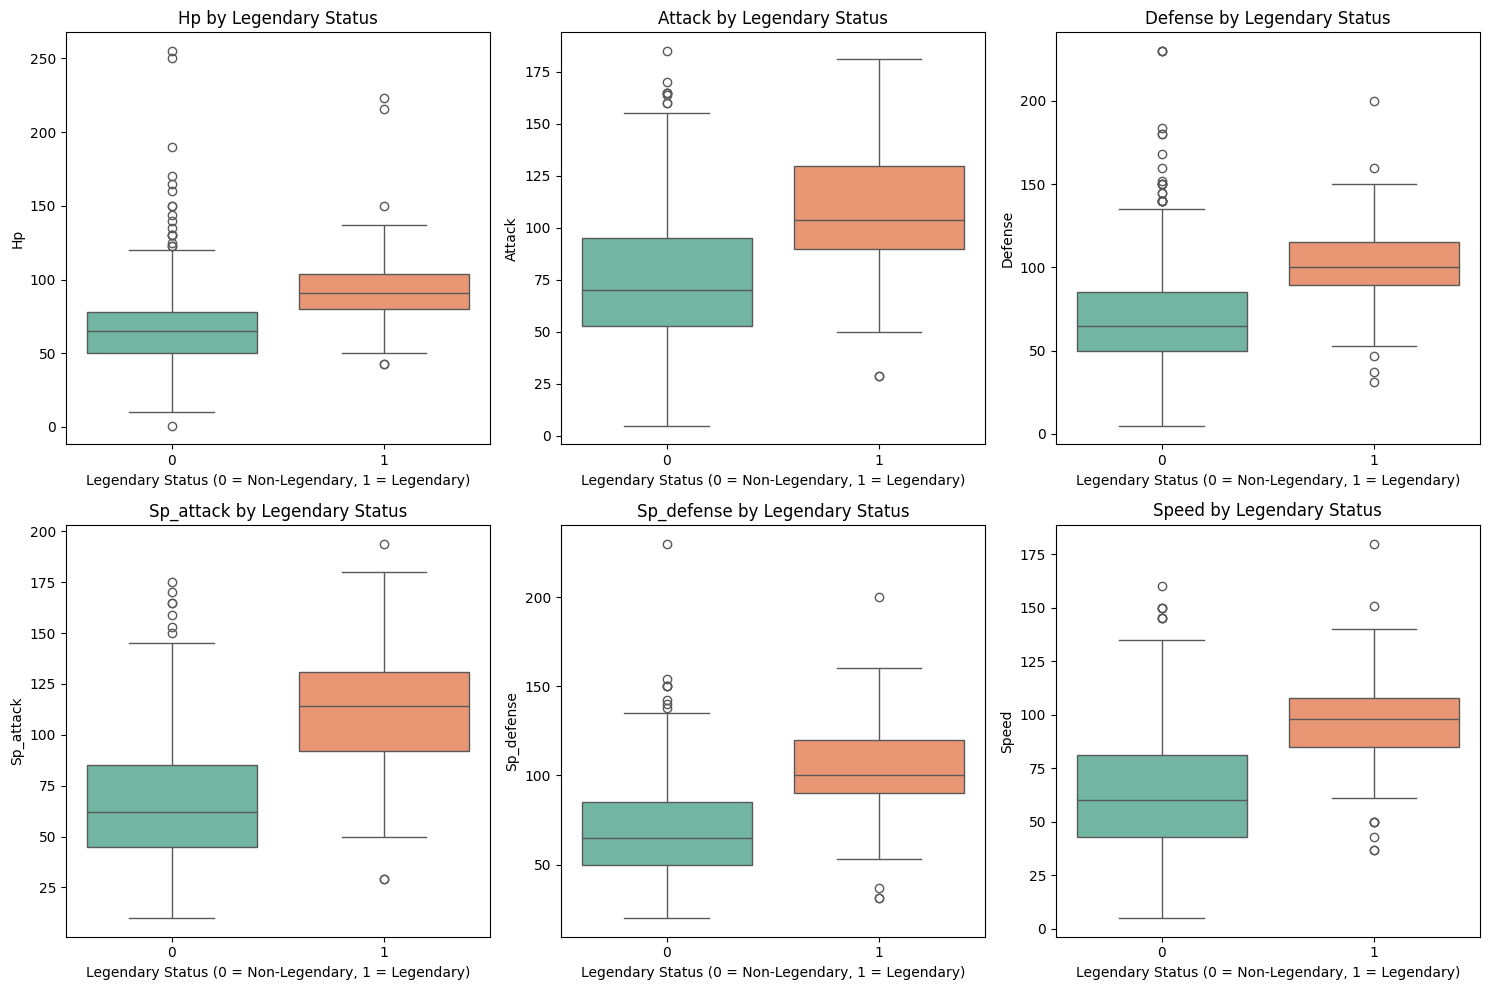

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Prepare the dataset (use your own Pokemon dataframe here)
df = pokemon_df.copy()

# Drop unnecessary columns and handle categorical variables
df = df.drop(['name', 'japanese_name', 'pokedex_number', 'abilities'], axis=1)

# Handle non-numeric columns (if any) before applying mean imputation
# Ensure we are only working with numeric columns
numeric_columns = df.select_dtypes(include=[np.number]).columns

# Fill missing values in numeric columns with the mean of each column
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Split the data into stats (features) and legendary status (target)
X = df[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']]
y = df['is_legendary']  # Target variable: 1 if legendary, 0 if not

# Part 1: T-Test/ANOVA for comparing stats between legendary and non-legendary Pokémon
legendary = df[df['is_legendary'] == 1]
non_legendary = df[df['is_legendary'] == 0]

# Perform T-tests for each stat between legendary and non-legendary Pokémon
stats = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
t_test_results = {}

for stat in stats:
    stat_legendary = legendary[stat]
    stat_non_legendary = non_legendary[stat]
    t_stat, p_val = ttest_ind(stat_legendary, stat_non_legendary)
    t_test_results[stat] = {'t-statistic': t_stat, 'p-value': p_val}

# Convert the T-test results into a DataFrame for better readability
t_test_df = pd.DataFrame(t_test_results).T
print("T-test Results:")
print(t_test_df)

# Interpretation of T-test results:
# If p-value < 0.05, the difference is statistically significant

# Part 2: Logistic Regression to predict legendary status based on stats
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = log_reg.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Display the results
print(f"Logistic Regression Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(report)

# Part 3: Visualization - Plotting the differences in stats between legendary and non-legendary Pokémon
plt.figure(figsize=(15, 10))

for i, stat in enumerate(stats):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='is_legendary', y=stat, data=df, palette="Set2")
    plt.title(f'{stat.capitalize()} by Legendary Status')
    plt.xlabel('Legendary Status (0 = Non-Legendary, 1 = Legendary)')
    plt.ylabel(stat.capitalize())

plt.tight_layout()
plt.show()


In [36]:
report = classification_report(y_test, y_pred, output_dict=True)

# Convert the classification report to a DataFrame for better display
classification_report_df = pd.DataFrame(report).transpose()
classification_report_df

,precision,recall,f1-score,support
0,0.910256,0.993007,0.949833,143.000000
1,0.800000,0.222222,0.347826,18.000000
accuracy,0.906832,0.906832,0.906832,0.906832
macro avg,0.855128,0.607615,0.648829,161.000000
weighted avg,0.897930,0.906832,0.882528,161.000000


In [37]:
t_test_results = {
    't-statistic': {
        'hp': 9.164280,
        'attack': 8.996885,
        'defense': 7.786876,
        'sp_attack': 12.568214,
        'sp_defense': 10.329799,
        'speed': 9.270647
    },
    'p-value': {
        'hp': 4.127358e-19,
        'attack': 1.663924e-18,
        'defense': 2.129723e-14,
        'sp_attack': 3.462358e-33,
        'sp_defense': 1.452898e-23,
        'speed': 1.684159e-19
    }
}

# Convert to DataFrame
t_test_df = pd.DataFrame(t_test_results)
t_test_df.index.name = 'Stat'
print(t_test_df)

            t-statistic       p-value
Stat                                 
hp             9.164280  4.127358e-19
attack         8.996885  1.663924e-18
defense        7.786876  2.129723e-14
sp_attack     12.568214  3.462358e-33
sp_defense    10.329799  1.452898e-23
speed          9.270647  1.684159e-19


In [38]:
def predict_legendary_status(pokemon_name, model, scaler, df):
    """
    Predicts whether a Pokémon is legendary or not based on its stats using the trained model.

    Parameters:
    - pokemon_name (str): The name of the Pokémon.
    - model (LogisticRegression): The trained logistic regression model.
    - scaler (StandardScaler): The scaler used to preprocess the data.
    - df (pd.DataFrame): The DataFrame containing the Pokémon stats and legendary status.

    Returns:
    - str: 'Legendary' or 'Non-Legendary' based on the model's prediction.
    """

    # Ensure the input name is in the correct format
    pokemon_name = pokemon_name.strip().lower()

    # Check if Pokémon exists in the dataframe
    if pokemon_name not in df['name'].str.lower().values:
        raise ValueError(f"Pokémon '{pokemon_name}' not found in the dataset.")

    # Extract the relevant stats for the given Pokémon
    pokemon_data = df[df['name'].str.lower() == pokemon_name][['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']]

    # Standardize the stats using the same scaler as during training
    pokemon_data_scaled = scaler.transform(pokemon_data)

    # Make the prediction using the trained logistic regression model
    prediction = model.predict(pokemon_data_scaled)

    # Return the result as 'Legendary' or 'Non-Legendary'
    if prediction == 1:
        return f"{pokemon_name.capitalize()} is Legendary!"
    else:
        return f"{pokemon_name.capitalize()} is Non-Legendary."

# Example usage:
pokemon_name = "heracross"  # Replace with the Pokémon name you want to check
result = predict_legendary_status(pokemon_name, log_reg, scaler, pokemon_df)
print(result)


Heracross is Non-Legendary.
